# Milestone 1 EDA: Second-Degree Connections

This notebook reframes the exploratory analysis around the actual project story: the value of second-degree connections in the Last.fm UK friendship network.

The goal is to answer three questions:

- how large is the reachable second-degree layer compared with direct friends?
- how much overlap remains when we filter by user attributes such as country and age group?
- which example users make the interaction legible enough for a first prototype?

## Important correction

The local workspace supports **age-group** and **country** matching directly, because these fields are present in `UsersData_anonymized`.

However, the local workspace does **not** contain a user-to-artist listening table, so user-level music-taste matching cannot be computed from the available files alone. That means the implemented analysis focuses on second-degree matching through age and country, while music-taste matching remains a documented next step if the listening-history file is added later.

In [1]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd()
summary = json.loads((ROOT / "data" / "milestone1_summary.json").read_text(encoding="utf-8"))

overview = pd.DataFrame(summary["overview"].items(), columns=["metric", "value"])
quality = pd.DataFrame(summary["quality_checks"].items(), columns=["check", "value"])
degree_hist = pd.DataFrame(summary["charts"]["degree_histogram"])
second_hist = pd.DataFrame(summary["charts"]["second_degree_histogram"])
shared_hist = pd.DataFrame(summary["charts"]["shared_attribute_histogram"])
age_groups = pd.DataFrame(summary["charts"]["age_group_distribution"])
countries = pd.DataFrame(summary["charts"]["top_countries"])
case_sizes = pd.DataFrame(summary["charts"]["prototype_case_sizes"])

In [2]:
display(overview)
display(quality)

,metric,value
0,users,76778
1,connected_users,75969
2,unique_friendships,389639
3,median_degree,5
4,median_second_degree,166


,check,value
0,missing_age,14952
1,missing_country,9
2,missing_gender,277
3,users_with_degree_zero,809


## Core takeaways

In [3]:
for idx, insight in enumerate(summary["insights"], start=1):
    print(f"{idx}. {insight}")

1. The cleaned graph contains 389,639 unique undirected friendships across 75,969 connected users.
2. The median user has 5 direct friends but 166 second-degree candidates, which supports the core idea that the real opportunity lies beyond the first hop.
3. Second-degree opportunity scales quickly: the 90th percentile user reaches 1,542 friends-of-friends after excluding direct ties.
4. Attribute overlap remains meaningful in the second-degree layer: the median user has 43 second-degree candidates sharing both country and age group.
5. The dataset is overwhelmingly UK-based, so country matching is informative for prototype logic but should not be over-interpreted as geographic diversity.


## Who is in the network?

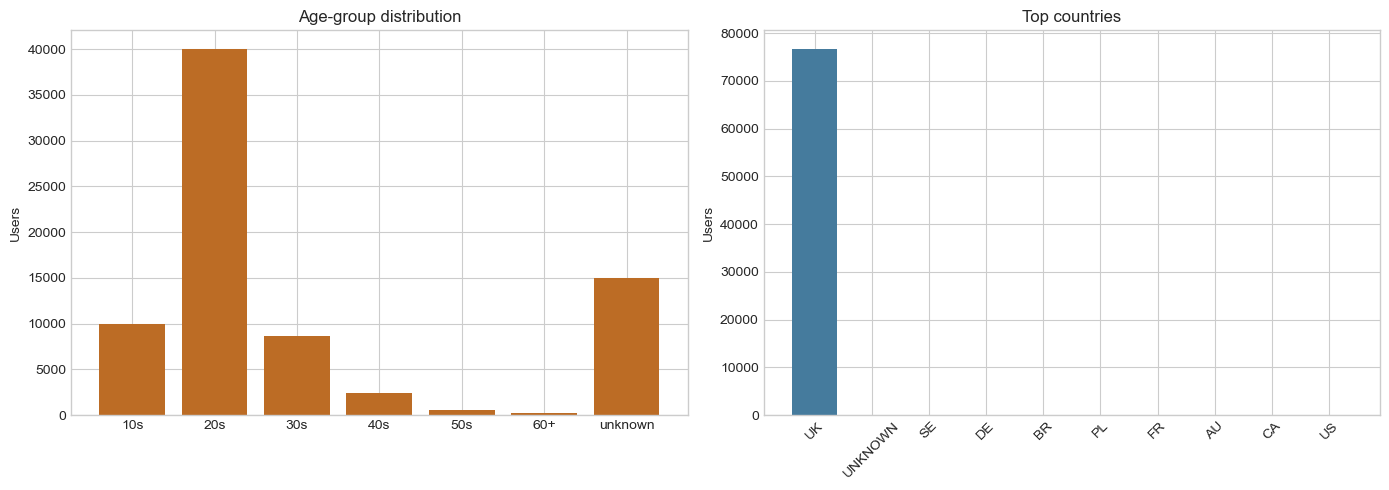

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(age_groups["label"], age_groups["value"], color="#bc6c25")
axes[0].set_title("Age-group distribution")
axes[0].set_ylabel("Users")

axes[1].bar(countries["label"], countries["value"], color="#457b9d")
axes[1].set_title("Top countries")
axes[1].set_ylabel("Users")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## How much bigger is the second-degree layer?

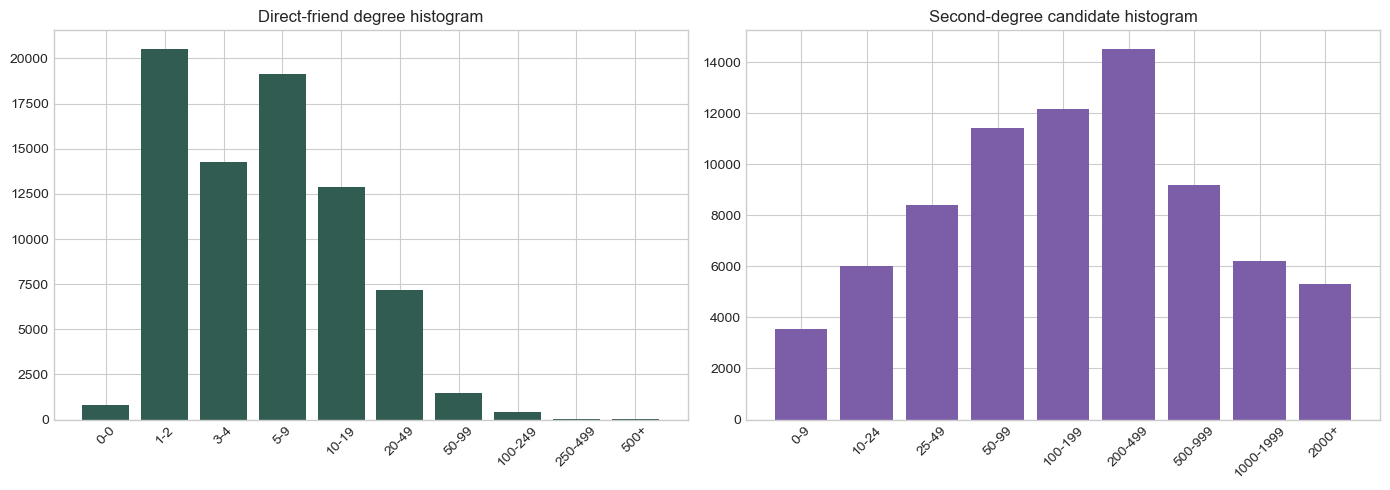

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(degree_hist["label"], degree_hist["value"], color="#315c52")
axes[0].set_title("Direct-friend degree histogram")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(second_hist["label"], second_hist["value"], color="#7b5ea7")
axes[1].set_title("Second-degree candidate histogram")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The second plot is the one that matters for the product concept. Even users with a moderate number of direct friendships can reach a much larger pool of second-degree candidates once the network is expanded by one hop.

## Shared attributes inside the second-degree layer

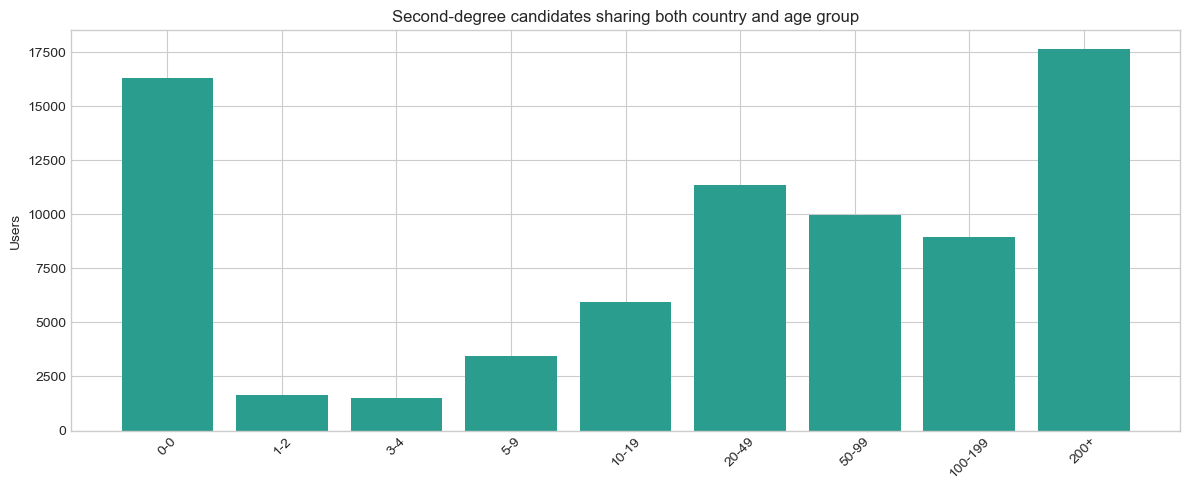

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(shared_hist["label"], shared_hist["value"], color="#2a9d8f")
ax.set_title("Second-degree candidates sharing both country and age group")
ax.set_ylabel("Users")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

This is the bridge from graph structure to human meaning: not all friends-of-friends are equally relevant. The product will surface the subset that is structurally reachable **and** socially plausible according to shared traits.

## Exemplar users for the prototype

These cases are selected because they are readable, have a useful number of direct and second-degree connections, and keep enough profile information for age/country matching.

In [7]:
display(case_sizes)

,label,direct_friends,second_degree_count,same_country_second_degree,same_age_group_second_degree
0,User 46455,11,216,16,15
1,User 60013,14,200,16,13
2,User 41599,15,194,16,16


In [8]:
cases = summary["prototype"]["cases"]
example_tables = []
for case in cases:
    table = pd.DataFrame(case["candidates"]).sort_values(
        ["shared_attribute_count", "mutual_friends", "degree"],
        ascending=[False, False, False],
    ).head(8)
    table.insert(0, "ego_user", case["user"]["id"])
    example_tables.append(table)

display(pd.concat(example_tables, ignore_index=True))

,ego_user,id,label,country,age_group,degree,mutual_friends,same_country,same_age_group,shared_attribute_count
0,46455,67974,User 67974,UK,20s,24,4,True,True,2
1,46455,44702,User 44702,UK,20s,78,2,True,True,2
2,46455,26989,User 26989,UK,20s,12,2,True,True,2
3,46455,43687,User 43687,UK,20s,10,2,True,True,2
4,46455,73750,User 73750,UK,20s,6,2,True,True,2
5,46455,51398,User 51398,UK,20s,1643,1,True,True,2
6,46455,3670,User 3670,UK,20s,310,1,True,True,2
7,46455,58786,User 58786,UK,20s,252,1,True,True,2
8,60013,10639,User 10639,UK,10s,199,5,True,True,2
9,60013,47859,User 47859,UK,10s,74,3,True,True,2


## Implication for the project direction

The exploratory analysis supports the team vision: the second-degree layer is much richer than the first-degree layer, and attribute-based filtering makes that larger space more meaningful.

The immediate implementation path is therefore:

1. let the user select an ego node
2. reveal direct and second-degree layers
3. filter second-degree candidates by shared country and/or age group
4. add music-taste matching as soon as a user-level listening table is available